## Predicting Pre-Owned Car Prices using Regression Models
A comparative regression modeling project focused on feature engineering and performance optimization.

### Regression Case Study

**Author:** Nikki Bhoot  
**Role:** Undergraduate Student | Aspiring Data Scientist   
**Project Type:** Supervised Machine Learning – Regression  
**Tools Used:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

---

## 📌 Project Objective

The objective of this project is to build and evaluate regression models to predict the resale price of used cars based on vehicle characteristics.

The workflow includes data cleaning, outlier treatment, feature engineering, and comparative model evaluation using RMSE and R² metrics.


## 📝 Problem Statement

Storm Motors, an online used car marketplace, aims to build a data-driven pricing model to accurately estimate the resale value of pre-owned vehicles.

The dataset consists of approximately 50,000 observations and includes both numerical and categorical variables such as:

- Year and month of registration
- Engine power (PS)
- Kilometers driven
- Fuel type
- Gearbox type
- Vehicle brand and model

Accurate price prediction is essential for competitive pricing, inventory valuation, and informed customer decision-making.

The objective is to develop regression models that capture both linear and non-linear relationships in the data and compare their predictive performance.

#### Importing Required Libraries


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")

#### Loading the Dataset


In [28]:
cars_data = pd.read_csv("cars_sampled.csv")
cars_data.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,postalCode,lastSeen
0,30/03/2016 13:51,Zu_verkaufen,private,offer,4450,test,limousine,2003,manual,150,3er,150000,3,diesel,bmw,NaN,30/03/2016 0:00,20257,7/4/2016 4:44
1,7/3/2016 9:54,Volvo_XC90_2.4D_Summum,private,offer,13299,control,suv,2005,manual,163,xc_reihe,150000,6,diesel,volvo,no,7/3/2016 0:00,88045,26/03/2016 13:17
2,1/4/2016 0:57,Volkswagen_Touran,private,offer,3200,test,bus,2003,manual,101,touran,150000,11,diesel,volkswagen,NaN,31/03/2016 0:00,27449,1/4/2016 8:40
3,19/03/2016 17:50,Seat_Ibiza_1.4_16V_Reference,private,offer,4500,control,small car,2006,manual,86,ibiza,60000,12,petrol,seat,no,19/03/2016 0:00,34537,7/4/2016 4:44
4,16/03/2016 14:51,Volvo_XC90_D5_Aut._RDesign_R_Design_AWD_GSHD_S...,private,offer,18750,test,suv,2008,automatic,185,xc_reihe,150000,11,diesel,volvo,no,16/03/2016 0:00,55270,1/4/2016 23:18


## 🔍 Data Overview

First, let us inspect the dataset structure, data types, and summary statistics to understand its characteristics.


In [29]:
cars = cars_data.copy()
cars.drop_duplicates(keep='first', inplace=True)

cars.shape
cars.info()
cars.describe()
cars.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 49999 entries, 0 to 50000
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   dateCrawled          49999 non-null  object
 1   name                 49999 non-null  object
 2   seller               49999 non-null  object
 3   offerType            49999 non-null  object
 4   price                49999 non-null  int64 
 5   abtest               49999 non-null  object
 6   vehicleType          44811 non-null  object
 7   yearOfRegistration   49999 non-null  int64 
 8   gearbox              47175 non-null  object
 9   powerPS              49999 non-null  int64 
 10  model                47241 non-null  object
 11  kilometer            49999 non-null  int64 
 12  monthOfRegistration  49999 non-null  int64 
 13  fuelType             45496 non-null  object
 14  brand                49999 non-null  object
 15  notRepairedDamage    40284 non-null  object
 16  dateCreat

dateCrawled               0
name                      0
seller                    0
offerType                 0
price                     0
abtest                    0
vehicleType            5188
yearOfRegistration        0
gearbox                2824
powerPS                   0
model                  2758
kilometer                 0
monthOfRegistration       0
fuelType               4503
brand                     0
notRepairedDamage      9715
dateCreated               0
postalCode                0
lastSeen                  0
dtype: int64

## 🧹 Data Cleaning

In this section, we:

- Remove irrelevant columns  
- Handle missing values  
- Filter unrealistic data entries  


In [30]:
cars = cars.drop(['name','dateCrawled', 'dateCreated', 'lastSeen', 'postalCode'], axis=1)
cars.head()

,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,private,offer,4450,test,limousine,2003,manual,150,3er,150000,3,diesel,bmw,NaN
1,private,offer,13299,control,suv,2005,manual,163,xc_reihe,150000,6,diesel,volvo,no
2,private,offer,3200,test,bus,2003,manual,101,touran,150000,11,diesel,volkswagen,NaN
3,private,offer,4500,control,small car,2006,manual,86,ibiza,60000,12,petrol,seat,no
4,private,offer,18750,test,suv,2008,automatic,185,xc_reihe,150000,11,diesel,volvo,no


In [31]:
cars['monthOfRegistration'] /= 12
cars['Age'] = (2018 - cars['yearOfRegistration']) + cars['monthOfRegistration']

cars = cars.drop(['yearOfRegistration', 'monthOfRegistration'], axis=1)

A new feature 'Age' is created using the year of registration.  
Vehicle age is a more meaningful predictor of price compared to raw registration year.

### Handling Missing Values

Two strategies are compared:

##### 1️⃣ Omitted Dataset
Rows with missing values are removed.

##### 2️⃣ Imputed Dataset
Missing values are filled using statistical techniques.


In [32]:
# Omitted version

cars_omit = cars.dropna()
print("Original shape:", cars.shape)
print("After omitting missing values:", cars_omit.shape)

Original shape: (49999, 13)
After omitting missing values: (35106, 13)


#### Removing Irrelevant Columns

Certain columns were removed based on their lack of predictive relevance:

- **offerType**: Contains almost identical values across all records (low variance).
- **abtest**: Nearly equal distribution with no significant difference in average price.
- **seller**: Highly imbalanced category with negligible impact on price.

Removing low-variance and irrelevant columns reduces noise and improves model generalization.

In [33]:
# Imputed Version

cars_imputed = cars.copy()
cars_imputed = cars_imputed.drop(['offerType', 'abtest', 'seller'], axis=1)

cars_imputed['vehicleType'] = cars_imputed['vehicleType'].fillna(cars_imputed['vehicleType'].mode()[0])
cars_imputed['gearbox'] = cars_imputed['gearbox'].fillna(cars_imputed['gearbox'].mode()[0])
cars_imputed['fuelType'] = cars_imputed['fuelType'].fillna(cars_imputed['fuelType'].mode()[0])
cars_imputed['model'] = cars_imputed['model'].fillna(cars_imputed['model'].mode()[0])

cars_imputed['powerPS'] = cars_imputed['powerPS'].fillna(cars_imputed['powerPS'].median())

cars_imputed.isnull().sum()

price                   0
vehicleType             0
gearbox                 0
powerPS                 0
model                   0
kilometer               0
fuelType                0
brand                   0
notRepairedDamage    9715
Age                     0
dtype: int64

## 📊 Exploratory Data Analysis (EDA)

We analyze important variables influencing car prices.


In [34]:
cars_imputed.shape
cars_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49999 entries, 0 to 50000
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              49999 non-null  int64  
 1   vehicleType        49999 non-null  object 
 2   gearbox            49999 non-null  object 
 3   powerPS            49999 non-null  int64  
 4   model              49999 non-null  object 
 5   kilometer          49999 non-null  int64  
 6   fuelType           49999 non-null  object 
 7   brand              49999 non-null  object 
 8   notRepairedDamage  40284 non-null  object 
 9   Age                49999 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 4.2+ MB


In [35]:
cars_imputed.describe()

,price,powerPS,kilometer,Age
count,4.999900e+04,49999.000000,49999.000000,49999.000000
mean,6.559934e+03,116.495970,125612.712254,12.934409
std,8.582018e+04,230.572012,40205.742765,123.001840
min,0.000000e+00,0.000000,5000.000000,-7981.000000
25%,1.150000e+03,69.000000,125000.000000,10.416667
50%,2.950000e+03,105.000000,150000.000000,15.083333
75%,7.190000e+03,150.000000,150000.000000,19.416667
max,1.234568e+07,19312.000000,150000.000000,1018.500000


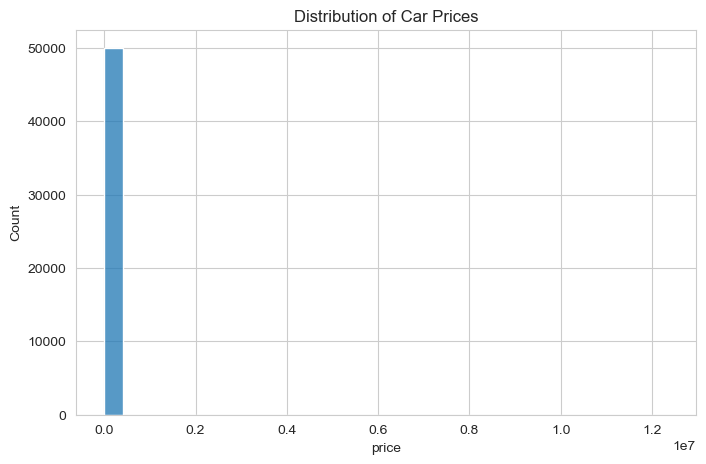

In [36]:
# Distribution of Variable - Price

plt.figure(figsize=(8,5))
sns.histplot(cars_imputed['price'], bins=30)
plt.title("Distribution of Car Prices")
plt.show()

##### Relationship with Important Numerical Variables

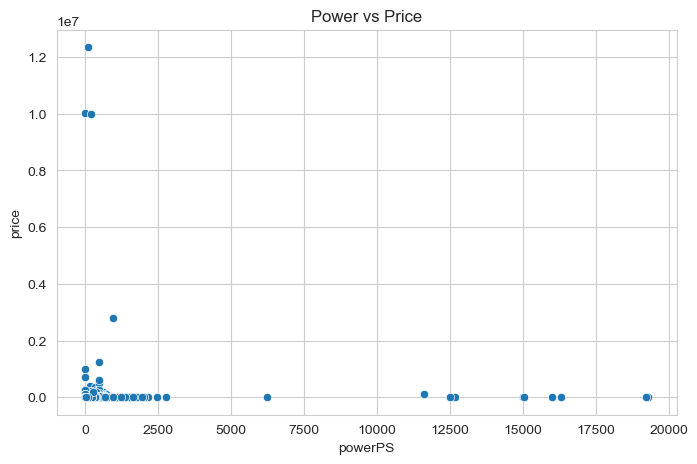

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='powerPS', y='price', data=cars_imputed)
plt.title("Power vs Price")
plt.show()

**Observation:**  
Most vehicles have lower power values.  
There are significant price outliers at higher power levels.  
Price generally increases with engine power.  


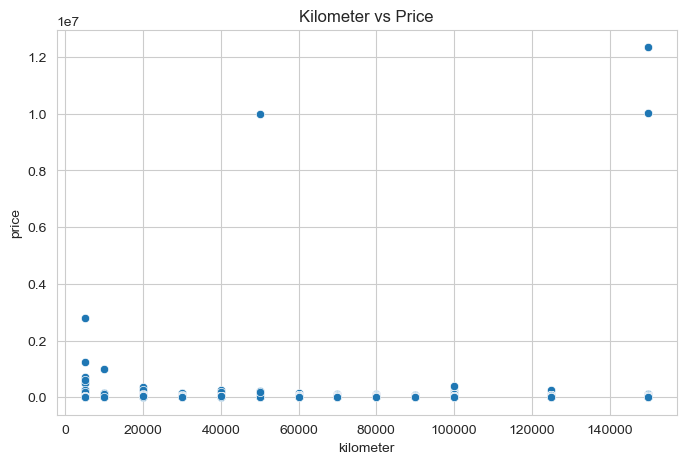

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='kilometer', y='price', data=cars_imputed)
plt.title("Kilometer vs Price")
plt.show()

**Observation:**  
Price decreases as kilometer driven increases.  
A negative relationship is observed.  
Some extreme price outliers are present.  


##### Categorical Impact

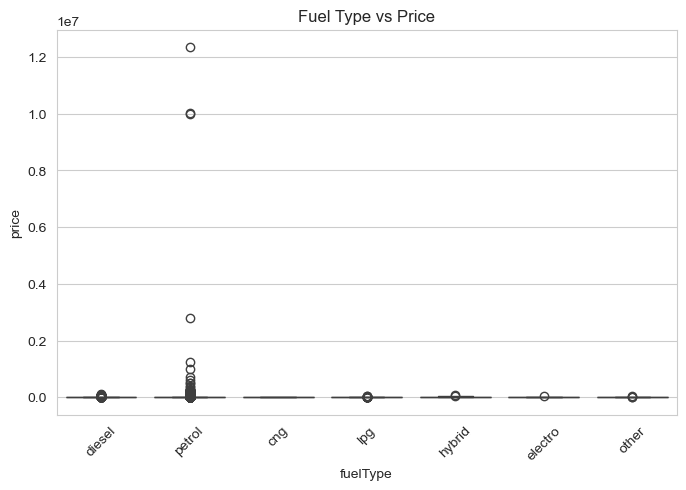

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fuelType', y='price', data=cars_imputed)
plt.xticks(rotation=45)
plt.title("Fuel Type vs Price")
plt.show()

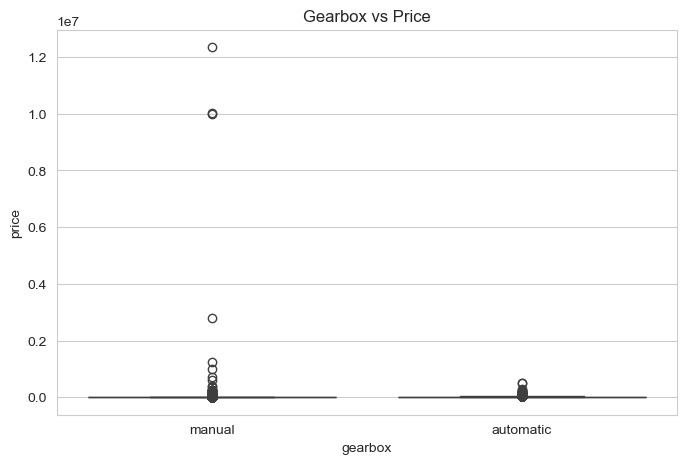

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gearbox', y='price', data=cars_imputed)
plt.title("Gearbox vs Price")
plt.show()

### Outlier Treatment

Extreme values in price and power may distort the regression model.
Therefore, unrealistic values are filtered before modeling.


In [41]:
# Removing extreme price values
cars_imputed = cars_imputed[(cars_imputed['price'] >= 100) & (cars_imputed['price'] <= 150000)]

# Removing extreme power values
cars_imputed = cars_imputed[(cars_imputed['powerPS'] >= 10) & (cars_imputed['powerPS'] <= 500)]

cars_imputed.shape

(43169, 10)

## Feature Encoding

Categorical variables are converted into dummy variables to make them suitable for regression modeling.


In [42]:
cars_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43169 entries, 0 to 50000
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              43169 non-null  int64  
 1   vehicleType        43169 non-null  object 
 2   gearbox            43169 non-null  object 
 3   powerPS            43169 non-null  int64  
 4   model              43169 non-null  object 
 5   kilometer          43169 non-null  int64  
 6   fuelType           43169 non-null  object 
 7   brand              43169 non-null  object 
 8   notRepairedDamage  36863 non-null  object 
 9   Age                43169 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 3.6+ MB


In [43]:
cars_encoded = pd.get_dummies(cars_imputed, drop_first=True)
cars_encoded.shape

(43169, 304)

#### Final Dataset for Modeling

After handling missing values, removing outliers, and encoding categorical variables, the dataset is ready for model training.


### Train-Test Split

The dataset is divided into training and testing sets.
70% of the data is used for training and 30% for testing.


In [44]:
X = cars_encoded.drop('price', axis=1)
y = np.log(cars_encoded['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape

((30218, 303), (12951, 303))

=> Since car prices are right-skewed, log transformation (log1p) 
was applied to stabilize variance and improve model performance.

## Linear Regression Model

A linear regression model is trained on the training dataset.


In [45]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [46]:
y_pred = model.predict(X_test)

### Model Evaluation

The model performance is evaluated using:
- Mean Squared Error (MSE)
- R² Score


In [47]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 0.4824586796095668
Root Mean Squared Error: 0.694592455767817
R² Score: 0.6519674814391643


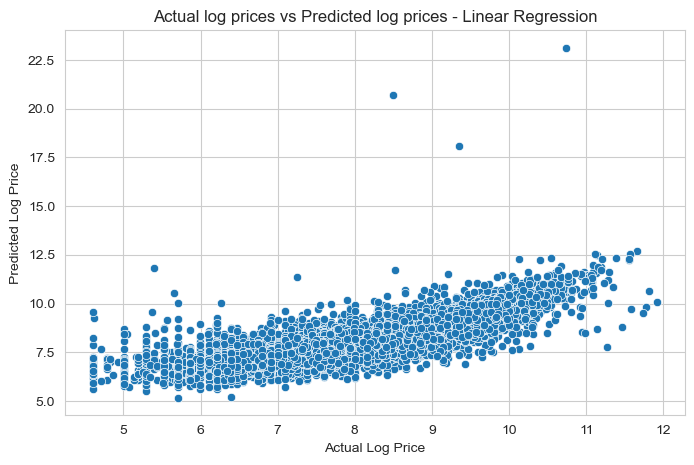

In [48]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual log prices vs Predicted log prices - Linear Regression")
plt.show()

#### Observation:

The scatter plot shows a positive linear relationship between actual and predicted log prices, 
indicating that the model successfully captures the overall trend in the data.

Predictions are slightly compressed toward the mean, indicating regression to the average — a typical behavior of linear models when extreme values are present.  
Higher priced vehicles show greater dispersion, indicating reduced accuracy in predicting premium cars.

The spread of points increases slightly as price increases, suggesting mild heteroscedasticity.

Overall, the model demonstrates moderate predictive performance with an R² score of 0.65.


### Linear Regression Model Summary

Target Variable: Log(Price)

R² Score: 0.651  
Root Mean Squared Error: 0.695  

Interpretation:

• The model explains approximately 65% of the variance in log-transformed car prices, indicating moderate predictive strength.
• Feature engineering (Age variable and filtering unrealistic registrations) improved model stability.  
• The model performs well for mid-range vehicles but struggles with extreme high-value cars.   
• Linear regression provides a solid baseline model for comparison with ensemble methods.  


### Random Forest Regression

To capture non-linear relationships and improve prediction performance, 
a Random Forest Regressor is trained and evaluated.


In [49]:
rf = RandomForestRegressor(n_estimators=100,max_features='sqrt',max_depth=100,min_samples_split=10,min_samples_leaf=4,random_state=42)

# Model
model_rf = rf.fit(X_train,y_train)

# Prediction model on test set
cars_predictions_rf = rf.predict(X_test)

# Computing MSE and RMSE
rf_mse = mean_squared_error(y_test,cars_predictions_rf)
rf_rmse = np.sqrt(rf_mse)
print(rf_rmse)

0.5535896971602922


In [50]:
rf_r2 = r2_score(y_test, cars_predictions_rf)
print(f"Random Forest R²: {rf_r2:.6f}")

Random Forest R²: 0.778927


### Interpretation

• Random Forest significantly improves predictive accuracy compared to Linear Regression.  
• The model captures non-linear relationships between vehicle attributes and price.  
• Ensemble learning reduces bias and improves robustness.  

The improvement in R² from 0.65 (Linear) to 0.78 (Random Forest) confirms the presence of non-linear relationships in the dataset.

# Final Model Comparison

| Model | R² Score | RMSE |
|-------|----------|------|
| Linear Regression | 0.652 | 0.695 |
| Random Forest | 0.778 | 0.553 |

### Conclusion

• Feature engineering (Age variable and filtering unrealistic entries) significantly improved baseline performance.   
• Linear Regression provides a strong and interpretable baseline model.  
• Random Forest achieved superior predictive accuracy by capturing non-linear relationships.    
• The results indicate that car prices are influenced by complex interactions beyond simple linear assumptions.  